In [ ]:
# Install necessary libraries if not already installed
!pip install -q mediapipe pandas scikit-learn tensorflow opencv-python matplotlib

In [1]:
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
import os
import cv2
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils import shuffle
import matplotlib.pyplot as plt

# Configure TensorFlow to use GPU and enable memory growth
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        # Currently, memory growth needs to be the same across GPUs
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        logical_gpus = tf.config.experimental.list_logical_devices('GPU')
        print(len(gpus), "Physical GPUs,", len(logical_gpus), "Logical GPUs")
    except RuntimeError as e:
        # Memory growth must be set before GPUs have been initialized
        print(e)
else:
    print("No GPU found for TensorFlow. Using CPU.")


2026-02-11 00:27:32.264185: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


1 Physical GPUs, 1 Logical GPUs


I0000 00:00:1770749864.967327    4838 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5560 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


In [ ]:
# Initialize MediaPipe Face Landmarker with byte-loading fix for Windows
model_path = '/face_landmarker.task'

try:
    with open(model_path, 'rb') as f:
        model_buffer = f.read()
    print(f"Successfully loaded model buffer. Size: {len(model_buffer)} bytes")
except FileNotFoundError:
    # Fallback if file is in current dir
    try:
        with open('face_landmarker.task', 'rb') as f:
            model_buffer = f.read()
        print("Successfully loaded model buffer from relative path.")
    except Exception as e:
        print(f"Error loading model: {e}")
        raise

BaseOptions = mp.tasks.BaseOptions
FaceLandmarker = mp.tasks.vision.FaceLandmarker
FaceLandmarkerOptions = mp.tasks.vision.FaceLandmarkerOptions
VisionRunningMode = mp.tasks.vision.RunningMode

options = FaceLandmarkerOptions(
    base_options=BaseOptions(model_asset_buffer=model_buffer),
    running_mode=VisionRunningMode.IMAGE,
    num_faces=1,
    min_face_detection_confidence=0.5,
    min_face_presence_confidence=0.5,
    min_tracking_confidence=0.5
)

landmarker = FaceLandmarker.create_from_options(options)
print("Face Landmarker initialized successfully.")


Successfully loaded model buffer. Size: 3758596 bytes
Face Landmarker initialized successfully.


W0000 00:00:1770749865.327479    4999 face_landmarker_graph.cc:174] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1770749865.371614    5003 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1770749865.438395    5015 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


In [ ]:
# Dataset Configuration
dataset_path = '/content/drive/MyDrive/datasets/grayscale_cls'
emotions = ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

# Helper function for Euclidean distance
def euc2d(a, b):
    return np.sqrt((a.x - b.x)**2 + (a.y - b.y)**2)

data = []
labels = []

print("Starting feature extraction...")

for emotion_idx, emotion in enumerate(emotions):
    emotion_dir = os.path.join(dataset_path, emotion)
    if not os.path.exists(emotion_dir):
        print(f"Warning: Directory not found: {emotion_dir}")
        continue
    
    print(f"Processing emotion: {emotion}")
    images = os.listdir(emotion_dir)
    
    for image_name in images:
        image_path = os.path.join(emotion_dir, image_name)
        try:
            cv_img = cv2.imread(image_path)
            if cv_img is None:
                continue
            
            # Convert to RGB
            cv_img_rgb = cv2.cvtColor(cv_img, cv2.COLOR_BGR2RGB)
            mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=cv_img_rgb)
            
            # Detect landmarks
            detection_result = landmarker.detect(mp_image)
            
            if detection_result.face_landmarks:
                landmarks = detection_result.face_landmarks[0]
                
                # Extract features: Flatten x, y coordinates
                features = []
                for lm in landmarks:
                    features.append(lm.x)
                    features.append(lm.y)
                
                data.append(features)
                labels.append(emotion_idx)
                
        except Exception as e:
            print(f"Error processing {image_path}: {e}")

print(f"Feature extraction complete. Total samples: {len(data)}")

Starting feature extraction...
Processing emotion: angry
Processing emotion: disgust
Processing emotion: fear
Processing emotion: happy
Processing emotion: neutral
Processing emotion: sad
Processing emotion: surprise
Feature extraction complete. Total samples: 13376


In [4]:
# Prepare Data
X = np.array(data)
y = np.array(labels)

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

# One-hot encoding
y_encoded = to_categorical(y, num_classes=len(emotions))

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

# Standardize features (important for MLP)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Data prepared for training.")

X shape: (13376, 956)
y shape: (13376,)
Data prepared for training.


In [5]:
# Build MLP Model
# Input dimension corresponds to 478 landmarks * 2 coordinate (x,y) = 956 features
model = Sequential([
    Dense(512, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dense(len(emotions), activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

/home/dinuk/miniconda3/envs/tf_gpu/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │       489,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 655,111 (2.50 MB)

 Trainable params: 655,111 (2.50 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50


2026-02-11 02:30:43.736700: I external/local_xla/xla/service/service.cc:163] XLA service 0x78108c00c3a0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-02-11 02:30:43.736948: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 4060 Laptop GPU, Compute Capability 8.9
2026-02-11 02:30:43.908024: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-02-11 02:30:44.528650: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91900
2026-02-11 02:30:44.933216: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-02-11 02:30:44.

 11/335 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.1917 - loss: 2.2442   

I0000 00:00:1770757256.913063    4997 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


335/335 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.2386 - loss: 2.0467

2026-02-11 02:31:06.382165: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-02-11 02:31:07.101345: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_82', 8 bytes spill stores, 8 bytes spill loads

2026-02-11 02:31:10.370084: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.


335/335 ━━━━━━━━━━━━━━━━━━━━ 37s 54ms/step - accuracy: 0.2669 - loss: 1.9089 - val_accuracy: 0.3247 - val_loss: 1.6942
Epoch 2/50
335/335 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.3220 - loss: 1.7008 - val_accuracy: 0.3359 - val_loss: 1.6640
Epoch 3/50
335/335 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3388 - loss: 1.6436 - val_accuracy: 0.3475 - val_loss: 1.6100
Epoch 4/50
335/335 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.3522 - loss: 1.6104 - val_accuracy: 0.3636 - val_loss: 1.5887
Epoch 5/50
335/335 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.3621 - loss: 1.5792 - val_accuracy: 0.3673 - val_loss: 1.5575
Epoch 6/50
335/335 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.3610 - loss: 1.5609 - val_accuracy: 0.3662 - val_loss: 1.5570
Epoch 7/50
335/335 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.3742 - loss: 1.5434 - val_accuracy: 0.3804 - val_loss: 1.5281
Epoch 8/50
335/335 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.3828 - loss: 1.5237 - val_accuracy: 0.3763 - 

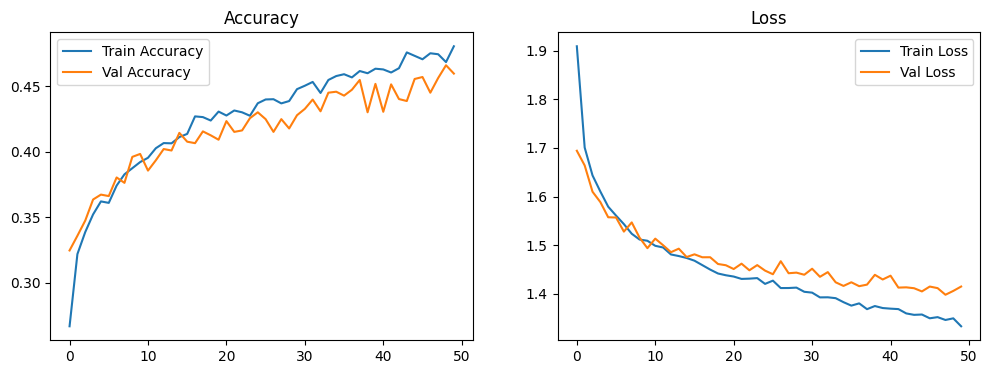

In [6]:
# Train Model
history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_data=(X_test, y_test))

# Plot Training History
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.legend()
plt.show()

In [7]:
# Final Evaluation
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_acc:.4f}")

84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4596 - loss: 1.4152
Test Accuracy: 0.4596
